In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [79]:
df = pd.read_csv("../data/processed/athlete_events_processed.csv")
df.head()

,ID,Name,Sex,Age,Height,Weight,NOC,Year,Season,City,Sport,Event,Medal_Bronze,Medal_Gold,Medal_None,Medal_Silver
0,1,A Dijiang,M,24.0,180.0,80.0,CHN,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,0,0,1,0
1,2,A Lamusi,M,23.0,170.0,60.0,CHN,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,0,0,1,0
2,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,NED,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,0,0,1,0
3,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,NED,1988,Winter,Calgary,Speed Skating,"Speed Skating Women's 1,000 metres",0,0,1,0
4,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,NED,1992,Winter,Albertville,Speed Skating,Speed Skating Women's 500 metres,0,0,1,0


In [80]:
df['Height_m'] = df['Height'] / 100

# calcolo il BMI
df['BMI'] = df['Weight'] / (df['Height_m'] ** 2)

nation_agg = df.groupby('Event').agg({
    'Age': 'mean',
    'BMI': 'mean',
    'Medal_Bronze': 'sum',
    'Medal_Gold': 'sum',
    'Medal_Silver': 'sum'
}).reset_index()

# totale medaglie e rimozione delle singole
#nation_agg['Total_Medals'] = (
 #   nation_agg['Medal_Bronze'] +
  #  nation_agg['Medal_Gold'] +
   # nation_agg['Medal_Silver']
#)

nation_agg = nation_agg.rename(columns={
    'Age': 'Mean_Age',
    'BMI': 'Mean_BMI'
}).drop(columns=['Medal_Bronze', 'Medal_Gold', 'Medal_Silver'])

nation_agg.head()

,Event,Mean_Age,Mean_BMI
0,Alpine Skiing Men's Combined,24.299528,25.729614
1,Alpine Skiing Men's Downhill,24.004464,25.016857
2,Alpine Skiing Men's Giant Slalom,23.134119,24.535158
3,Alpine Skiing Men's Slalom,23.343028,24.491246
4,Alpine Skiing Men's Super G,24.536842,25.516195


In [ ]:
from sklearn.preprocessing import MinMaxScaler

features = ['Mean_Age', 'Mean_BMI']

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(nation_agg[features])

event_scaled = pd.DataFrame(X_scaled, columns=features, index=nation_agg.index)

event_scaled['Event'] = nation_agg['Event']

print(event_scaled.head())


   Mean_Age  Mean_BMI                             Event
0  0.303942  0.368234      Alpine Skiing Men's Combined
1  0.288607  0.337312      Alpine Skiing Men's Downhill
2  0.243371  0.316415  Alpine Skiing Men's Giant Slalom
3  0.254229  0.314510        Alpine Skiing Men's Slalom
4  0.316276  0.358975       Alpine Skiing Men's Super G


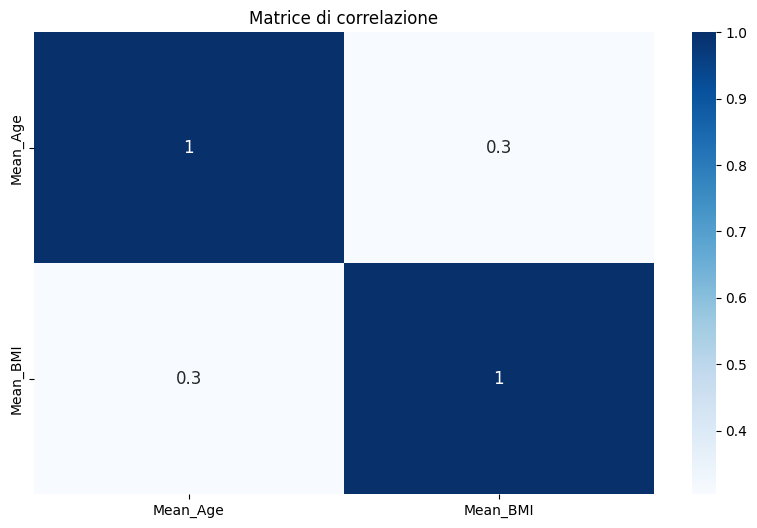

In [82]:
import seaborn as sns

plt.figure(figsize=(10,6))
ax = sns.heatmap(event_scaled.drop(columns=['Event']).corr(), cmap="Blues", annot=True, annot_kws={"size": 12})

plt.title('Matrice di correlazione')
plt.show()


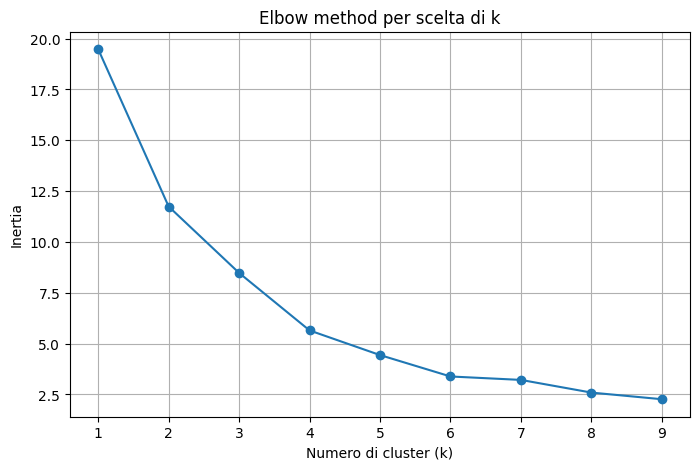

In [83]:
from sklearn.cluster import KMeans
X = event_scaled[['Mean_Age', 'Mean_BMI']].values

inertias = []
K = range(1, 10)  # ad es. da 1 a 9 cluster

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)  # somma delle distanze al centroide

plt.figure(figsize=(8, 5))
plt.plot(K, inertias, marker='o')
plt.xlabel('Numero di cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow method per scelta di k')
plt.xticks(K)
plt.grid(True)
plt.show()

In [84]:
from sklearn.cluster import KMeans

X = event_scaled[['Mean_Age', 'Mean_BMI']].values

kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X)

event_scaled['Cluster'] = labels

In [85]:
cluster_profile = event_scaled.groupby('Cluster')[['Mean_Age', 'Mean_BMI']].mean()
print(cluster_profile)

         Mean_Age  Mean_BMI
Cluster                    
0        0.169787  0.173199
1        0.728002  0.292822
2        0.372741  0.232971
3        0.416443  0.569904


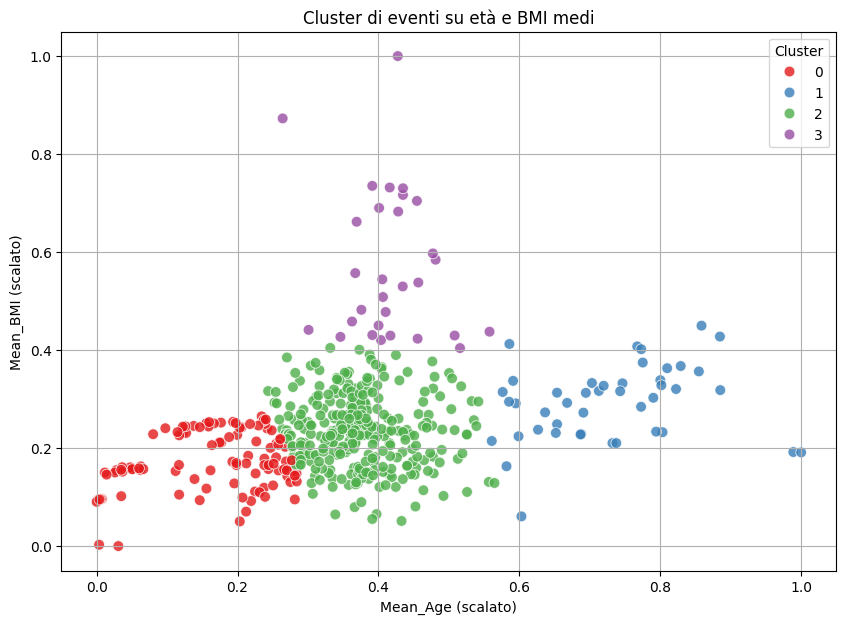

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=event_scaled,
    x='Mean_Age',
    y='Mean_BMI',
    hue='Cluster',
    palette='Set1',
    s=60,
    alpha=0.8
)


plt.title('Cluster di eventi su età e BMI medi')
plt.xlabel('Mean_Age (scalato)')
plt.ylabel('Mean_BMI (scalato)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()